In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import files

# Загрузка данных MNIST
from torchvision import datasets, transforms

# Загрузка MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Определение модели
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение модели
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_acc:.2f}%')

# Тестирование модели
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total
print(f'Точность на MNIST (тест): {test_acc:.4f}')

# Сохранение весов
torch.save(model.state_dict(), 'ultra.pth')
print("Веса сохранены в ultra.pth")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


Epoch 1/3, Loss: 0.2143, Accuracy: 93.52%
Epoch 2/3, Loss: 0.0615, Accuracy: 98.11%
Epoch 3/3, Loss: 0.0435, Accuracy: 98.64%
Точность на MNIST (тест): 0.9915
Веса сохранены в ultra.pth


In [6]:
import cv2
from scipy.ndimage import center_of_mass, shift

def preprocess_paint_png(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Файл не прочитан. Проверьте имя/путь.")

    # сглаживание
    img = cv2.GaussianBlur(img, (3,3), 0)

    # авто-инверсия
    if img.mean() > 127:
        img = 255 - img

    _, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # ищем рамку цифры
    coords = cv2.findNonZero(bw)
    if coords is None:
        raise ValueError("На изображении не найдено пикселей цифры (после порога).")

    x, y, w, h = cv2.boundingRect(coords)
    digit = bw[y:y+h, x:x+w]

    # делаем квадрат с полем
    size = max(w, h) + 8
    square = np.zeros((size, size), dtype=np.uint8)
    x_off = (size - w) // 2
    y_off = (size - h) // 2
    square[y_off:y_off+h, x_off:x_off+w] = digit

    resized = cv2.resize(square, (20,20), interpolation=cv2.INTER_AREA)
    padded = np.pad(resized, ((4,4),(4,4)), mode="constant")

    cy, cx = center_of_mass(padded)
    if np.isnan(cx) or np.isnan(cy):
        raise ValueError("Проблема с центром масс (пустое изображение после обработки).")

    shift_y = 14 - cy
    shift_x = 14 - cx
    centered = shift(padded, shift=(shift_y, shift_x), order=0, mode="constant", cval=0)

    # нормирование
    x_in = (centered.astype("float32") / 255.0).reshape(1, 1, 28, 28)

    return x_in, centered

Saving 8.png to 8.png
Файл: 8.png


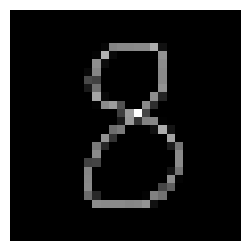

Распознано: 8
Уверенность: 0.34859469532966614
Вероятности по классам:
0 : 0.04113084077835083
1 : 0.022579465061426163
2 : 0.1111661046743393
3 : 0.19537648558616638
4 : 0.024785052984952927
5 : 0.08540790528059006
6 : 0.06605999171733856
7 : 0.03297892212867737
8 : 0.34859469532966614
9 : 0.07192054390907288


In [9]:
uploaded = files.upload()
fname = list(uploaded.keys())[0]
print("Файл:", fname)

x_in, dbg = preprocess_paint_png(fname)

# показываем, что реально подаётся в сеть
plt.figure(figsize=(3,3))
plt.imshow(dbg, cmap="gray")
plt.axis("off")
plt.show()

# Предсказание
model.eval()
x_tensor = torch.FloatTensor(x_in).to(device)
with torch.no_grad():
    output = model(x_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    pred = probabilities.cpu().numpy()[0]

digit = int(np.argmax(pred))
conf = float(np.max(pred))

print("Распознано:", digit)
print("Уверенность:", conf)

print("Вероятности по классам:")
for i, p in enumerate(pred):
    print(i, ":", float(p))